<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/DNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Imports ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [ ]:
# --- Load Data ---
df = pd.read_csv('allDataMean.csv')
data = df[['allDataMean6']].values

In [ ]:
# --- Normalize ---
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [ ]:

# --- Create Sequences ---
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 20
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
# --- Train-Test Split ---
split = int(len(X) * 0.8)
x_train = X[:split].reshape((-1, seq_length))
x_test = X[split:].reshape((-1, seq_length))
y_train, y_test = y[:split], y[split:]

In [ ]:
# --- DNN Model ---
model = Sequential()
model.add(Dense(128, activation='relu', input_shape=(seq_length,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# --- Train ---
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1)

Epoch 1/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 8.5266e-08 - val_loss: 2.3877e-07
Epoch 2/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.1709e-07 - val_loss: 1.1992e-07
Epoch 3/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 1.0405e-07 - val_loss: 2.2896e-08
Epoch 4/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1.0109e-07 - val_loss: 4.0861e-08
Epoch 5/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 9.3233e-08 - val_loss: 5.1268e-08
Epoch 6/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.1940e-07 - val_loss: 3.1750e-08
Epoch 7/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1.0877e-07 - val_loss: 2.3137e-08
Epoch 8/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 7.9352e-08 - val_loss: 3.1332e-08
Epoch 9/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 8.2369e-08 - val_loss: 2.7318e-08
Epoch 10/50
2075/2075 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.1502e-07 - val_loss: 3.9678e-08
Epoch 11/50
2075/2075 ━━━━━━━━━━━━━━

In [ ]:
# --- Predict ---
y_pred = model.predict(x_test)
y_pred_inv = scaler.inverse_transform(y_pred)
y_test_inv = scaler.inverse_transform(y_test)

1153/1153 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [ ]:
# --- Metrics ---
mae = mean_absolute_error(y_test_inv, y_pred_inv)
mse = mean_squared_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f"DNN MAE: {mae:.4f}")
print(f"DNN MSE: {mse:.4f}")
print(f"DNN R²: {r2:.4f}")

DNN MAE: 1.9918
DNN MSE: 60.7998
DNN R²: 0.9443


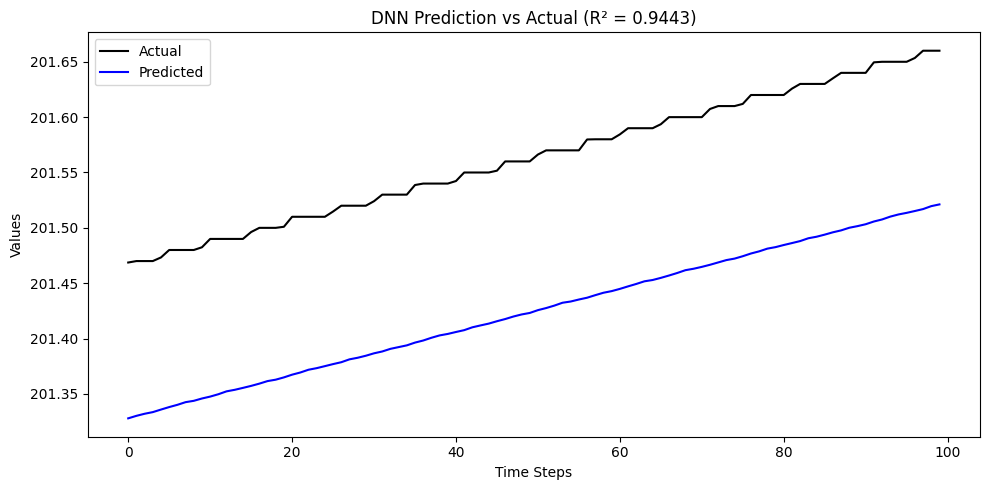

In [ ]:
# --- Line Plot ---
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv[:100], label='Actual', color='black')
plt.plot(y_pred_inv[:100], label='Predicted', color='blue')
plt.title(f"DNN Prediction vs Actual (R² = {r2:.4f})")
plt.xlabel("Time Steps")
plt.ylabel("Values")
plt.legend()
plt.tight_layout()
plt.show()


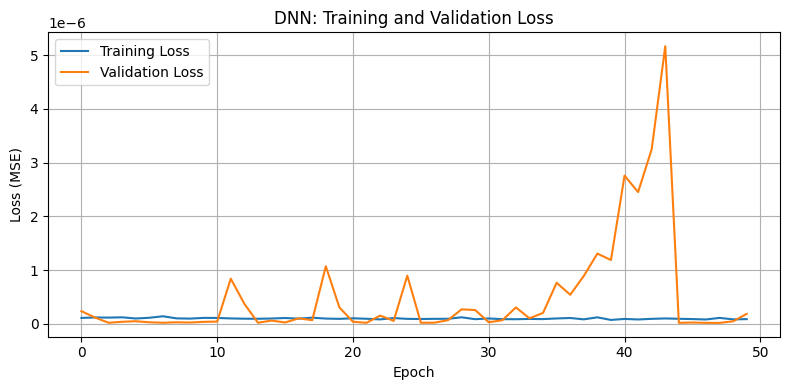

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("DNN: Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()